<a href="https://colab.research.google.com/github/lkostenko/KMA/blob/main/ltv_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LTV Cohort Analysis

Існує кілька варіантів прогнозування LTV:

## Формульний підхід

**Формула:**

LTV = price × platform_fee × tax × CR × rebill × refund_rate

де:
- price — ціна продукту  
- platform_fee — комісії платформи  
- tax —  податки по країнам
- CR — конверсія в оплату  
- rebill — коефіцієнт повторних оплат  
- refund_rate — частка повернень  



### Розрахунок Rebill

Rebill рахується як ланцюговий добуток step-конверсій:

rebill = 1 + s₁₂ + s₁₂·s₂₃ + s₁₂·s₂₃·s₃₄ + ...

де:
- sᵢⱼ — конверсія з періоду i в j  

---

## Крива накопичення LTV

Крива може бути апроксимована логарифмічною або степеневою функцією (наприклад, у Google Sheets).

**Модель:**

`LTV(t) = L · (1 − e^(−k·(t+1)))`




## 1. Імпорти та налаштування

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

FILE            = "Data Analyst Test Task Data new – Kostenko.xlsx"
SHEET           = "Tasks 1-2"
WEEKLY_HORIZON  = 26   # тижнів
MONTHLY_HORIZON = 6    # місяців
MIN_COHORT_SIZE = 20   # розмір когорти для графіків
MIN_FIT_POINTS  = 3    # точок для фіту


## 2. Модель: Exp Saturation

```
LTV(t) = L · (1 − e^(−k·(t+1)))
```

- **L** — асимптота (теоретичний максимум LTV когорти)  
- **k** — швидкість виходу на плато (більший k = швидше насичення)  
- При `t → ∞`: LTV → L  
- При малих t: крива майже лінійна з нахилом `L·k`


In [ ]:
def exp_sat(t, L, k):
    return L * (1 - np.exp(-k * (t + 1)))


## 3. Завантаження та очищення даних

In [ ]:
df = pd.read_excel(FILE, sheet_name=SHEET)
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"])

refunds = (df[df["event_name"] == "refund"]
           [["refunded_transaction_id", "revenue_usd"]]
           .rename(columns={"refunded_transaction_id": "transaction_id",
                             "revenue_usd": "refund_amount"}))
purchases = df[df["event_name"] == "purchase"].copy()
purchases = purchases.merge(refunds, on="transaction_id", how="left")
purchases["net_revenue"] = purchases["revenue_usd"] + purchases["refund_amount"].fillna(0)

first_payments = (
    purchases[purchases["net_revenue"] > 0]
    .groupby("uuid")["event_timestamp"].min()
    .reset_index()
    .rename(columns={"event_timestamp": "cohort_start_time"})
)
df_clean = purchases.merge(first_payments, on="uuid", how="inner")

print(f"Платних юзерів:  {len(first_payments):,}")
print(f"Платіжних рядків: {len(df_clean):,}")
print(f"Дата-рейндж:     {df_clean['cohort_start_time'].min().date()} – {df_clean['cohort_start_time'].max().date()}")


Платних юзерів:  2,367
Платіжних рядків: 15,740
Дата-рейндж:     2023-03-01 – 2023-10-16


## 4. Фактичний LTV по когортах

In [ ]:
def get_actual_ltv(data, period="W"):
    temp = data.copy()
    if period == "W":
        temp["cohort"] = temp["cohort_start_time"].dt.to_period("W").apply(lambda r: r.start_time)
        temp["age"]    = ((temp["event_timestamp"] - temp["cohort_start_time"]).dt.days // 7).astype(int)
    else:
        temp["cohort"] = temp["cohort_start_time"].dt.to_period("M").apply(lambda r: r.start_time)
        temp["age"]    = ((temp["event_timestamp"] - temp["cohort_start_time"]).dt.days // 30).astype(int)
    temp = temp[temp["age"] >= 0]
    sizes = (temp.groupby("cohort")["uuid"].nunique()
             .reset_index().rename(columns={"uuid": "cohort_size"}))
    rev = temp.groupby(["cohort", "age"])["net_revenue"].sum().reset_index()
    rev = rev.sort_values(["cohort", "age"])
    rev["cum_revenue"] = rev.groupby("cohort")["net_revenue"].cumsum()
    ltv = rev.merge(sizes, on="cohort")
    ltv["actual_ltv"] = ltv["cum_revenue"] / ltv["cohort_size"]
    return ltv[["cohort", "age", "actual_ltv", "cohort_size"]]

weekly_ltv  = get_actual_ltv(df_clean, "W")
monthly_ltv = get_actual_ltv(df_clean, "M")

print(f"Тижневих когорт: {weekly_ltv['cohort'].nunique()}")
print(f"Місячних когорт: {monthly_ltv['cohort'].nunique()}")


Тижневих когорт: 34
Місячних когорт: 8


## 5. Фітинг та предикт

In [ ]:
def fit_cohort(x, y):
    """
    Фітує Exp Saturation. Повертає (L, k, r2) або (None, None, None).
    Початкові умови: L = max(y)*1.3, k = 0.1
    Нижня межа k=0.01 щоб уникнути вироджених рішень при малій кількості точок.
    """
    p0     = [y.max() * 1.3, 0.1]
    bounds = ([0, 0.01], [np.inf, np.inf])
    try:
        popt, _ = curve_fit(exp_sat, x, y, p0=p0, maxfev=10_000, bounds=bounds)
        L, k    = popt
        y_fit   = exp_sat(x, L, k)
        ss_res  = np.sum((y - y_fit) ** 2)
        ss_tot  = np.sum((y - np.mean(y)) ** 2)
        r2      = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return L, k, r2
    except Exception:
        return None, None, None

def fit_and_predict(ltv_df, horizon):
    rows = []
    for cohort in sorted(ltv_df["cohort"].unique()):
        sub = ltv_df[ltv_df["cohort"] == cohort].sort_values("age")
        x, y = sub["age"].values.astype(float), sub["actual_ltv"].values.astype(float)
        if len(x) < MIN_FIT_POINTS:
            continue
        L, k, r2 = fit_cohort(x, y)
        if L is None:
            continue
        for age in range(horizon + 1):
            rows.append({
                "cohort":        cohort,
                "age":           age,
                "predicted_ltv": exp_sat(age, L, k),
                "cohort_size":   sub["cohort_size"].iloc[0],
                "r2":            r2,
                "L":             L,
                "k":             k,
                "observed_ages": len(x),
            })
    return pd.DataFrame(rows)

weekly_pred  = fit_and_predict(weekly_ltv,  WEEKLY_HORIZON)
monthly_pred = fit_and_predict(monthly_ltv, MONTHLY_HORIZON)

print("Якість фіту R² — тижневі (топ за розміром когорти):")
qw = (weekly_pred.drop_duplicates("cohort")
      .sort_values("cohort_size", ascending=False)
      .head(10)[["cohort","cohort_size","observed_ages","L","k","r2"]])
qw["cohort"] = qw["cohort"].dt.strftime("%d %b %Y")
qw[["L","k"]] = qw[["L","k"]].round(2)
qw["r2"] = qw["r2"].round(4)
print(qw.to_string(index=False))

print("\nЯкість фіту R² — місячні:")
qm = (monthly_pred.drop_duplicates("cohort")
      [["cohort","cohort_size","observed_ages","L","k","r2"]])
qm["cohort"] = qm["cohort"].dt.strftime("%Y-%m")
qm[["L","k"]] = qm[["L","k"]].round(2)
qm["r2"] = qm["r2"].round(4)
print(qm.to_string(index=False))


Якість фіту R² — тижневі (топ за розміром когорти):
     cohort  cohort_size  observed_ages     L    k     r2
06 Mar 2023          237             36 45.70 0.07 0.9967
15 May 2023          211             26 33.00 0.09 0.9923
20 Mar 2023          177             34 33.39 0.08 0.9929
13 Mar 2023          174             35 41.26 0.07 0.9956
01 May 2023          172             27 31.02 0.10 0.9904
08 May 2023          172             27 29.40 0.11 0.9891
22 May 2023          164             25 39.97 0.07 0.9909
24 Apr 2023          159             29 45.72 0.06 0.9952
17 Apr 2023          138             30 43.82 0.08 0.9963
27 Mar 2023          131             33 38.90 0.08 0.9946

Якість фіту R² — місячні:
 cohort  cohort_size  observed_ages     L    k     r2
2023-03          734              9 40.57 0.31 0.9988
2023-04          528              8 41.29 0.33 0.9978
2023-05          736              7 32.37 0.41 0.9958
2023-06          247              6 30.15 0.44 0.9926
2023-07      

## 6. Backtest (holdout validation)

In [ ]:
def backtest(ltv_df):
    rows = []
    for cohort in sorted(ltv_df["cohort"].unique()):
        sub = ltv_df[ltv_df["cohort"] == cohort].sort_values("age")
        x, y = sub["age"].values.astype(float), sub["actual_ltv"].values.astype(float)
        n_fit = max(MIN_FIT_POINTS, len(x) // 2)
        if len(x) - n_fit < 1:
            continue
        L, k, r2_fit = fit_cohort(x[:n_fit], y[:n_fit])
        if L is None:
            continue
        holdout_actual = y[n_fit:]
        holdout_pred   = exp_sat(x[n_fit:], L, k)
        mape = np.mean(np.abs((holdout_actual - holdout_pred) / holdout_actual)) * 100
        rows.append({
            "cohort":       cohort,
            "cohort_size":  sub["cohort_size"].iloc[0],
            "n_fit":        n_fit,
            "n_holdout":    len(holdout_actual),
            "r2_fit":       round(r2_fit, 4),
            "mape_%":       round(mape, 1),
        })
    return pd.DataFrame(rows)

bt_w = backtest(weekly_ltv)
bt_m = backtest(monthly_ltv)

print("Backtest — тижневі (топ 10 за розміром):")
bw = bt_w.copy(); bw["cohort"] = bw["cohort"].dt.strftime("%d %b %Y")
print(bw.sort_values("cohort_size", ascending=False).head(10).to_string(index=False))

print("\nBacktest — місячні:")
bm = bt_m.copy(); bm["cohort"] = bm["cohort"].dt.strftime("%Y-%m")
print(bm.to_string(index=False))


Backtest — тижневі (топ 10 за розміром):
     cohort  cohort_size  n_fit  n_holdout  r2_fit  mape_%
06 Mar 2023          237     18         18  0.9893     2.3
15 May 2023          211     13         13  0.9753     2.8
20 Mar 2023          177     17         17  0.9797     5.6
13 Mar 2023          174     17         18  0.9852     0.8
01 May 2023          172     13         14  0.9693     1.6
08 May 2023          172     13         14  0.9738     9.3
22 May 2023          164     12         13  0.9641     7.5
24 Apr 2023          159     14         15  0.9792     4.8
17 Apr 2023          138     15         15  0.9896     2.5
27 Mar 2023          131     16         17  0.9828     2.1

Backtest — місячні:
 cohort  cohort_size  n_fit  n_holdout  r2_fit  mape_%
2023-03          734      4          5  0.9994     1.4
2023-04          528      4          4  0.9995     1.7
2023-05          736      3          4  0.9976     1.9
2023-06          247      3          3  0.9944     6.8
2023-07       

## 7. Допоміжні функції для графіків

In [ ]:
def fitted_big(ltv_df, pred_df):
    """Когорти з розміром >= MIN_COHORT_SIZE що є в pred_df."""
    fitted = set(pred_df["cohort"].unique())
    big    = ltv_df.groupby("cohort")["cohort_size"].first()
    big    = big[big >= MIN_COHORT_SIZE].index
    return [c for c in big if c in fitted]

def cohort_cmap(cohorts):
    cmap = cm.get_cmap("tab20", max(len(cohorts), 1))
    return {c: cmap(i) for i, c in enumerate(sorted(cohorts))}

def fmt_label(cohort, period):
    return pd.to_datetime(cohort).strftime("%b %d" if period == "W" else "%b %Y")


## 8. Графік — тижневі когорти

Суцільна = факт, штрихова = Exp Saturation до 26 тижнів.  
Горизонтальна пунктирна = асимптота **L** (теоретичний максимум LTV).


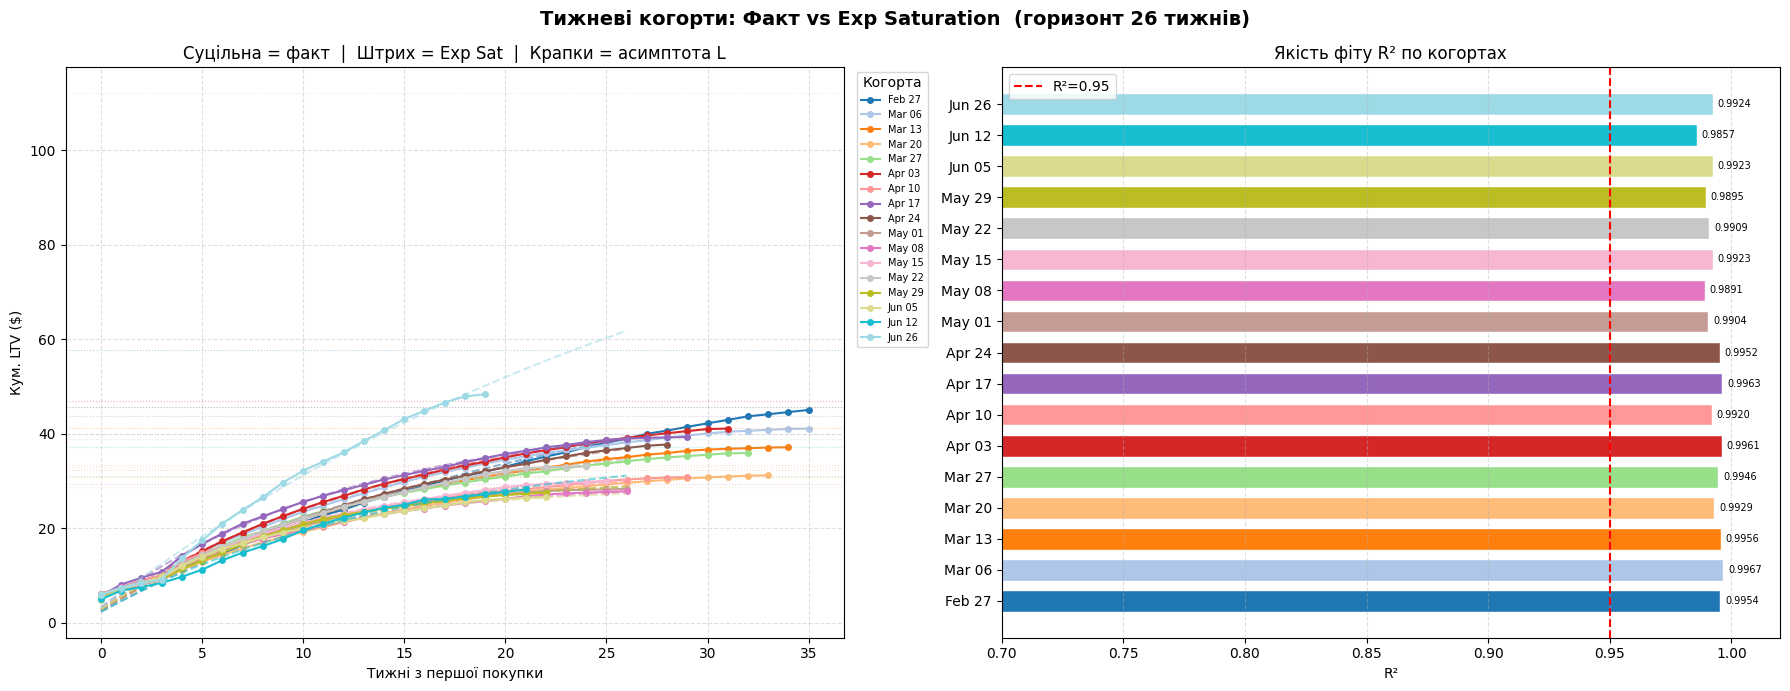

In [ ]:
big_w  = fitted_big(weekly_ltv, weekly_pred)
cmap_w = cohort_cmap(big_w)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Тижневі когорти: Факт vs Exp Saturation  (горизонт 26 тижнів)",
             fontsize=14, fontweight="bold")

ax = axes[0]
t_ext = np.linspace(0, WEEKLY_HORIZON, 300)
for cohort in sorted(big_w):
    act  = weekly_ltv[weekly_ltv["cohort"] == cohort].sort_values("age")
    pred = weekly_pred[weekly_pred["cohort"] == cohort].sort_values("age")
    col  = cmap_w[cohort]
    L    = pred["L"].iloc[0]
    ax.plot(act["age"],  act["actual_ltv"],    "-o", ms=4, color=col,
            label=fmt_label(cohort, "W"))
    ax.plot(pred["age"], pred["predicted_ltv"], "--",       color=col, alpha=0.55)
    ax.axhline(L, color=col, ls=":", lw=0.8, alpha=0.35)

ax.set_xlabel("Тижні з першої покупки")
ax.set_ylabel("Кум. LTV ($)")
ax.set_title("Суцільна = факт  |  Штрих = Exp Sat  |  Крапки = асимптота L")
ax.grid(True, ls="--", alpha=0.4)
ax.legend(title="Когорта", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

ax2 = axes[1]
q = weekly_pred.drop_duplicates("cohort")
q = q[q["cohort"].isin(big_w)].sort_values("cohort")
cols_bar = [cmap_w[c] for c in q["cohort"]]
bars = ax2.barh([fmt_label(c,"W") for c in q["cohort"]],
                q["r2"], color=cols_bar, edgecolor="white", height=0.7)
ax2.axvline(0.95, color="red", ls="--", lw=1.5, label="R²=0.95")
for bar, val in zip(bars, q["r2"]):
    ax2.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=7)
ax2.set_xlabel("R²")
ax2.set_title("Якість фіту R² по когортах")
ax2.set_xlim(0.7, 1.02)
ax2.grid(True, axis="x", ls="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()


## 9. Графік — місячні когорти

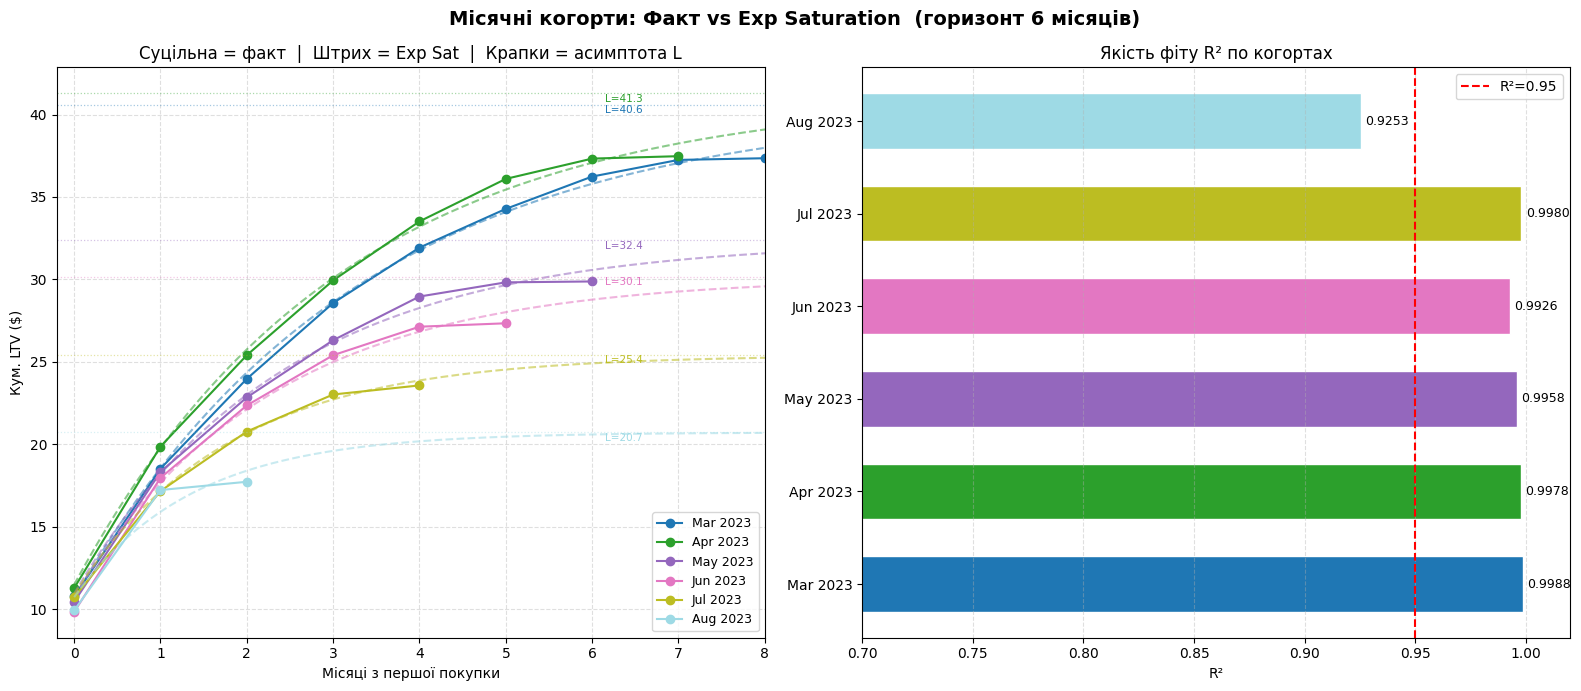

In [ ]:
big_m  = fitted_big(monthly_ltv, monthly_pred)
cmap_m = cohort_cmap(big_m)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Місячні когорти: Факт vs Exp Saturation  (горизонт 6 місяців)",
             fontsize=14, fontweight="bold")

ax = axes[0]
t_ext = np.linspace(0, 12, 300)
for cohort in sorted(big_m):
    act  = monthly_ltv[monthly_ltv["cohort"] == cohort].sort_values("age")
    pred = monthly_pred[monthly_pred["cohort"] == cohort].sort_values("age")
    L, k = pred["L"].iloc[0], pred["k"].iloc[0]
    col  = cmap_m[cohort]
    ax.plot(act["age"],  act["actual_ltv"],    "-o", ms=6, color=col,
            label=fmt_label(cohort, "M"))
    ax.plot(t_ext, exp_sat(t_ext, L, k), "--", color=col, alpha=0.55)
    ax.axhline(L, color=col, ls=":", lw=0.9, alpha=0.4)
    ax.text(MONTHLY_HORIZON + 0.15, L - 0.5, f"L={L:.1f}",
            color=col, fontsize=7.5)

ax.set_xlabel("Місяці з першої покупки")
ax.set_ylabel("Кум. LTV ($)")
ax.set_title("Суцільна = факт  |  Штрих = Exp Sat  |  Крапки = асимптота L")
ax.set_xlim(-0.2, 8)
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=9)

ax2 = axes[1]
q = monthly_pred.drop_duplicates("cohort")
q = q[q["cohort"].isin(big_m)].sort_values("cohort")
cols_bar = [cmap_m[c] for c in q["cohort"]]
bars = ax2.barh([fmt_label(c,"M") for c in q["cohort"]],
                q["r2"], color=cols_bar, edgecolor="white", height=0.6)
ax2.axvline(0.95, color="red", ls="--", lw=1.5, label="R²=0.95")
for bar, val in zip(bars, q["r2"]):
    ax2.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9)
ax2.set_xlabel("R²")
ax2.set_title("Якість фіту R² по когортах")
ax2.set_xlim(0.7, 1.02)
ax2.grid(True, axis="x", ls="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()


## 10. Backtest — візуальна валідація

Фіт по першій половині точок → предикт другої половини → MAPE.


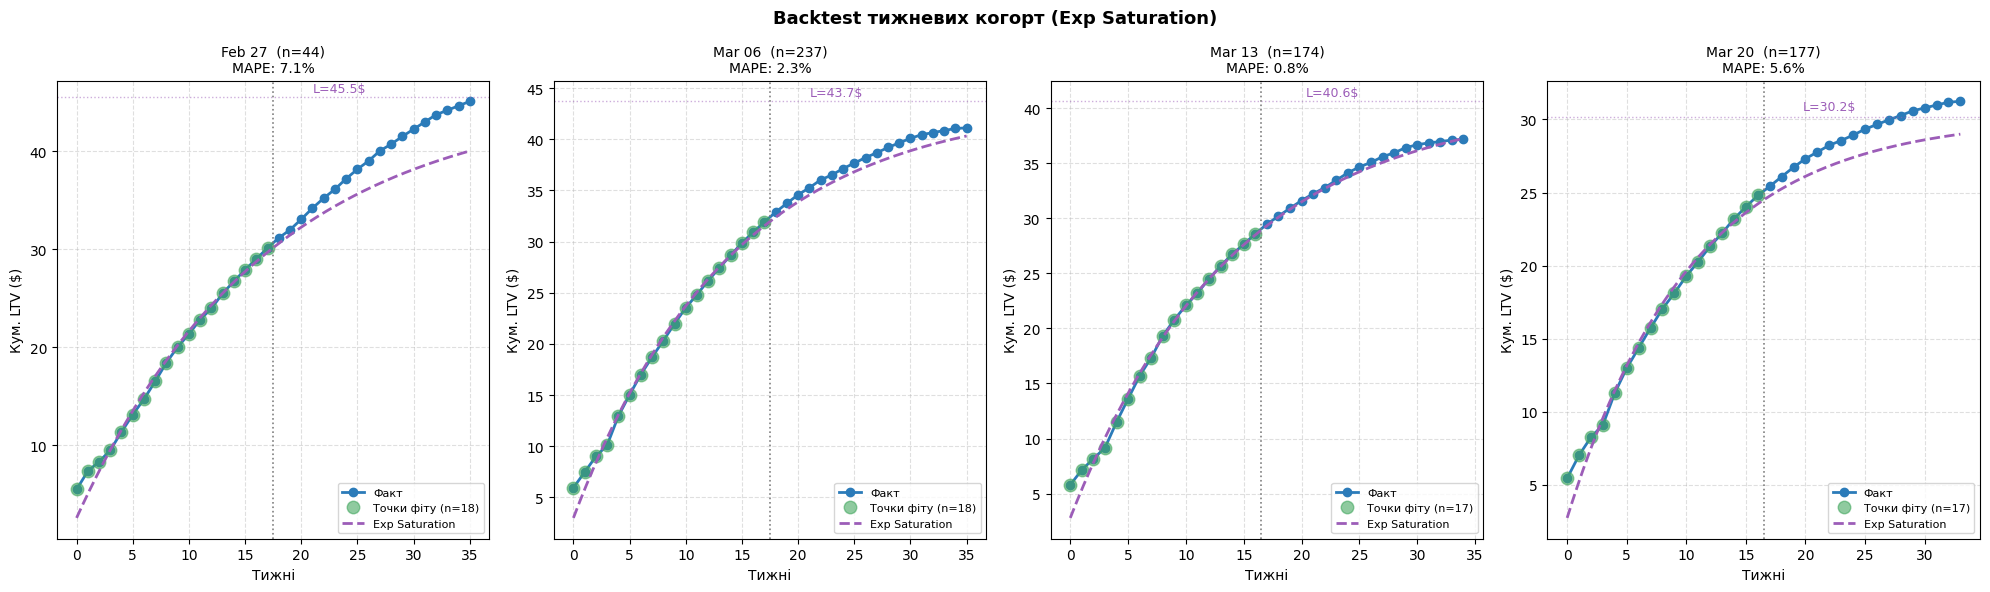

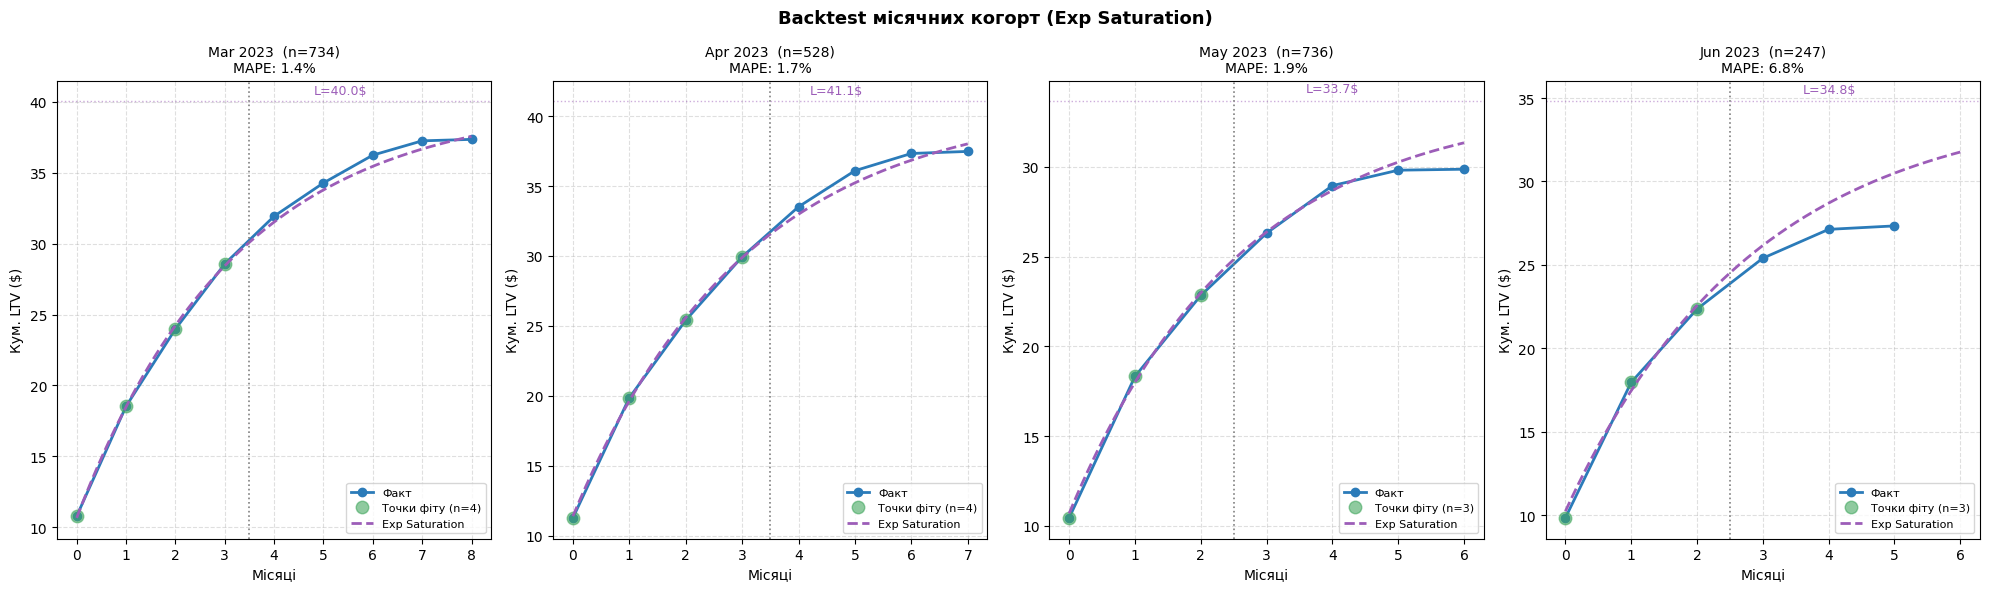

In [ ]:
def plot_backtest_panel(ltv_df, pred_df, period, n_panels=4):
    big    = fitted_big(ltv_df, pred_df)
    # беремо когорти з найбільшою кількістю точок
    obs    = ltv_df.groupby("cohort")["age"].max()
    top    = obs[obs.index.isin(big)].sort_values(ascending=False).head(n_panels).index

    fig, axes = plt.subplots(1, len(top), figsize=(5*len(top), 6))
    if len(top) == 1: axes = [axes]
    xlabel = "Тижні" if period == "W" else "Місяці"
    horizon = WEEKLY_HORIZON if period == "W" else MONTHLY_HORIZON
    fig.suptitle(f"Backtest {'тижневих' if period=='W' else 'місячних'} когорт "
                 f"(Exp Saturation)", fontsize=13, fontweight="bold")

    for ax, cohort in zip(axes, top):
        sub = ltv_df[ltv_df["cohort"] == cohort].sort_values("age")
        x, y = sub["age"].values.astype(float), sub["actual_ltv"].values.astype(float)
        n    = sub["cohort_size"].iloc[0]
        n_fit = max(MIN_FIT_POINTS, len(x) // 2)

        L, k, _ = fit_cohort(x[:n_fit], y[:n_fit])
        if L is None: continue

        x_ext = np.linspace(0, max(horizon, x[-1]), 300)

        holdout_actual = y[n_fit:]
        holdout_pred   = exp_sat(x[n_fit:], L, k)
        mape = np.mean(np.abs((holdout_actual - holdout_pred) / holdout_actual)) * 100

        ax.plot(x, y, "o-", color="#2B7BB9", lw=2, label="Факт")
        ax.plot(x[:n_fit], y[:n_fit], "o", color="#44A860", ms=9,
                alpha=0.6, label=f"Точки фіту (n={n_fit})")
        ax.plot(x_ext, exp_sat(x_ext, L, k), "--", color="#9C5DB8",
                lw=2, label="Exp Saturation")
        ax.axhline(L, color="#9C5DB8", ls=":", lw=1, alpha=0.5)
        ax.text(x_ext[-1]*0.6, L+0.5, f"L={L:.1f}$", color="#9C5DB8", fontsize=9)
        ax.axvline(n_fit - 0.5, color="gray", ls=":", lw=1.2)

        title_str = f"{fmt_label(cohort, period)}  (n={n})\nMAPE: {mape:.1f}%"
        ax.set_title(title_str, fontsize=10)
        ax.set_xlabel(xlabel); ax.set_ylabel("Кум. LTV ($)")
        ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_backtest_panel(weekly_ltv,  weekly_pred,  "W")
plot_backtest_panel(monthly_ltv, monthly_pred, "M")


## 11. Предиктований LTV на горизонті

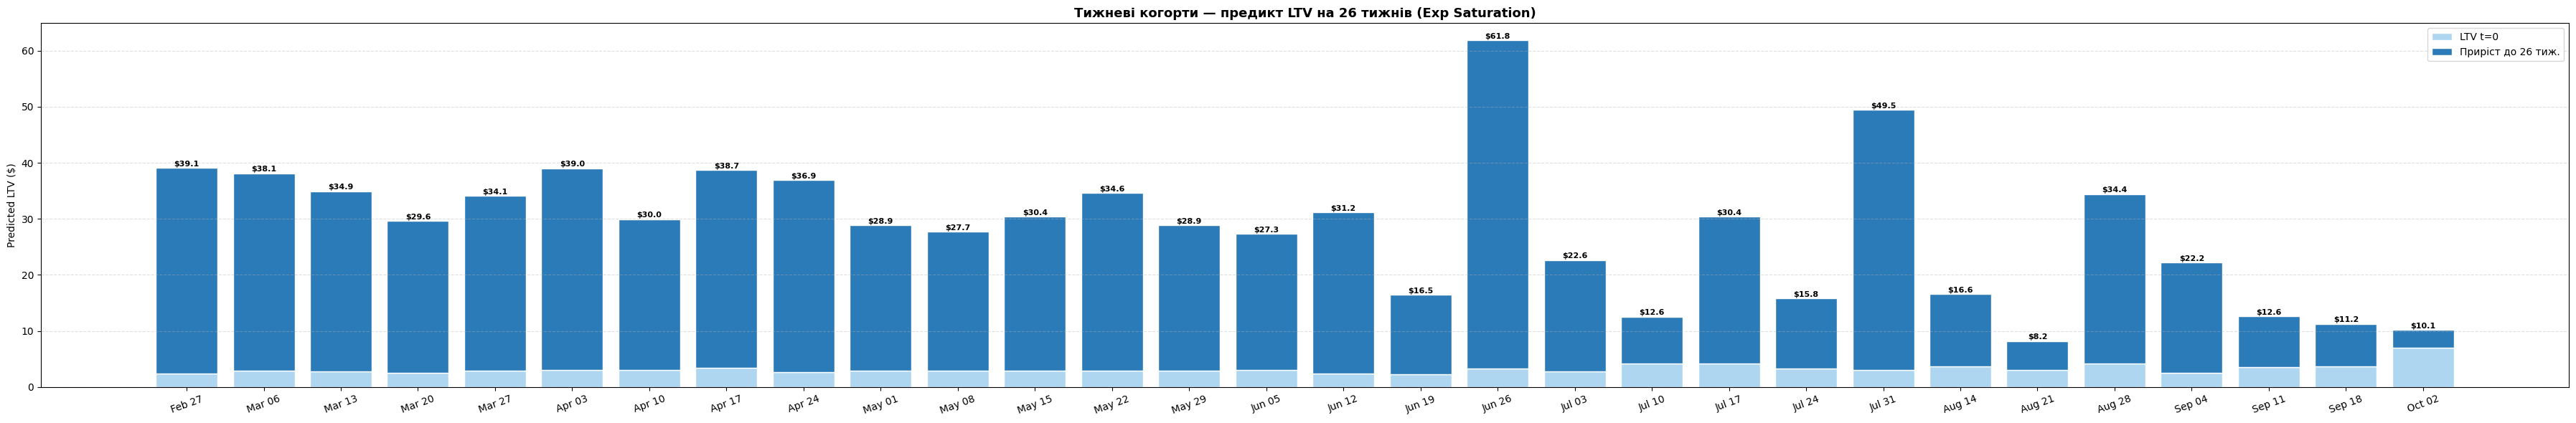

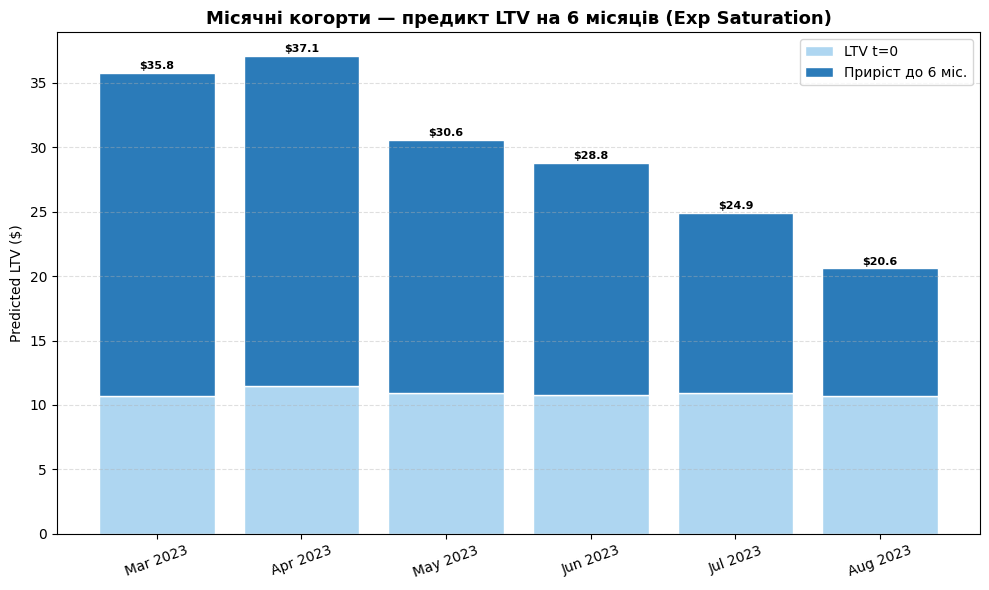

In [ ]:
def horizon_bar(pred_df, period, title):
    horizon = WEEKLY_HORIZON if period == "W" else MONTHLY_HORIZON
    end = pred_df[pred_df["age"] == horizon].copy()
    t0  = (pred_df[pred_df["age"] == 0][["cohort","predicted_ltv"]]
           .rename(columns={"predicted_ltv": "ltv_0"}))
    df  = end.merge(t0, on="cohort")
    df["label"] = df["cohort"].dt.strftime("%b %d" if period=="W" else "%b %Y")

    fig, ax = plt.subplots(figsize=(max(10, len(df)*1.2), 6))
    x = range(len(df))
    lbl = "26 тиж." if period == "W" else "6 міс."
    ax.bar(x, df["ltv_0"],
           label="LTV t=0", color="#AED6F1", edgecolor="white")
    ax.bar(x, df["predicted_ltv"] - df["ltv_0"], bottom=df["ltv_0"],
           label=f"Приріст до {lbl}", color="#2B7BB9", edgecolor="white")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["label"], rotation=20)
    ax.set_ylabel("Predicted LTV ($)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(True, axis="y", ls="--", alpha=0.4)
    for i, row in df.iterrows():
        idx = list(df.index).index(i)
        ax.text(idx, row["predicted_ltv"]+0.3, f"${row['predicted_ltv']:.1f}",
                ha="center", fontsize=8, fontweight="bold")
    plt.tight_layout(); plt.show()

horizon_bar(weekly_pred,  "W", "Тижневі когорти — предикт LTV на 26 тижнів (Exp Saturation)")
horizon_bar(monthly_pred, "M", "Місячні когорти — предикт LTV на 6 місяців (Exp Saturation)")


## 12. Тренд асимптоти L по когортах

Параметр **L** = теоретичний максимум LTV когорти. Його динаміка в часі показує
чи погіршується / покращується якість нових когорт.


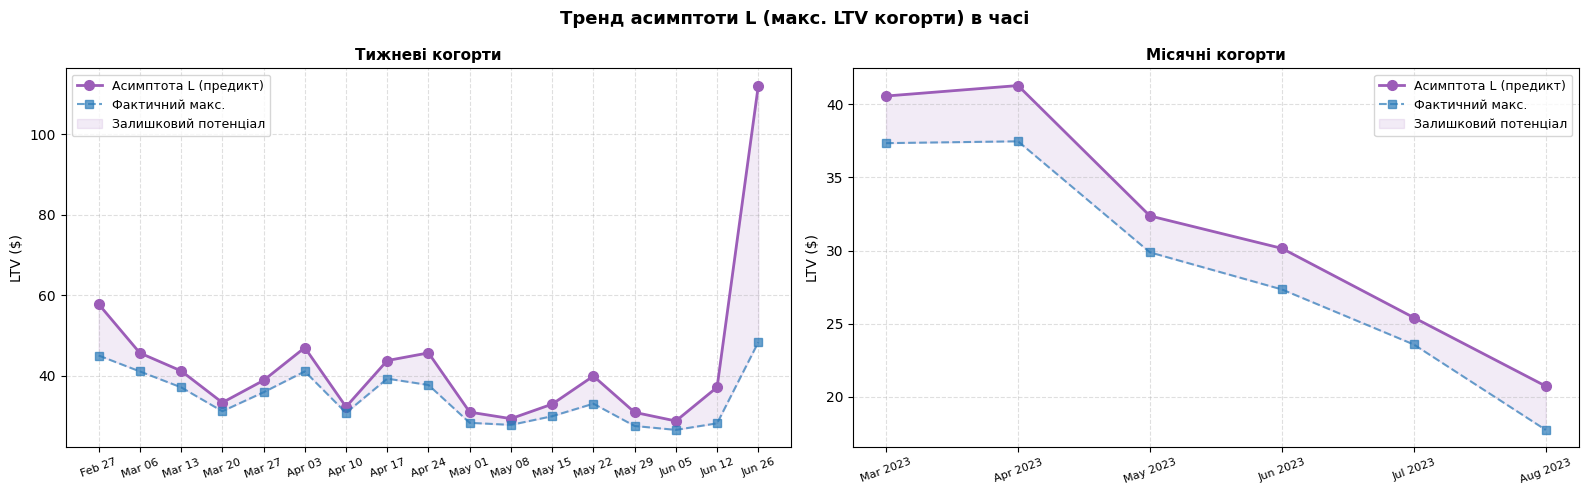

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Тренд асимптоти L (макс. LTV когорти) в часі",
             fontsize=13, fontweight="bold")

for ax, pred_df, ltv_df, period, title in [
    (axes[0], weekly_pred,  weekly_ltv,  "W", "Тижневі когорти"),
    (axes[1], monthly_pred, monthly_ltv, "M", "Місячні когорти"),
]:
    big = fitted_big(ltv_df, pred_df)
    q   = (pred_df.drop_duplicates("cohort")
           [pred_df["cohort"].isin(big)]
           .sort_values("cohort"))

    actual_max = ltv_df.groupby("cohort")["actual_ltv"].max().reset_index()
    q = q.merge(actual_max, on="cohort", suffixes=("","_act"))

    ax.plot(range(len(q)), q["L"], "o-", color="#9C5DB8", lw=2,
            ms=7, label="Асимптота L (предикт)")
    ax.plot(range(len(q)), q["actual_ltv"], "s--", color="#2B7BB9", lw=1.5,
            ms=6, alpha=0.7, label="Фактичний макс.")
    ax.fill_between(range(len(q)), q["actual_ltv"], q["L"],
                    alpha=0.12, color="#9C5DB8", label="Залишковий потенціал")

    ax.set_xticks(range(len(q)))
    ax.set_xticklabels([fmt_label(c, period) for c in q["cohort"]],
                       rotation=20, fontsize=8)
    ax.set_ylabel("LTV ($)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


## 13. Зведені таблиці

In [ ]:
def build_summary(ltv_df, pred_df, period):
    horizon = WEEKLY_HORIZON if period == "W" else MONTHLY_HORIZON
    mid     = horizon // 2
    fmt     = "%d %b %Y" if period == "W" else "%Y-%m"
    label   = "тиж." if period == "W" else "міс."
    rows = []
    for cohort in sorted(pred_df["cohort"].unique()):
        p = pred_df[pred_df["cohort"] == cohort]
        a = ltv_df[ltv_df["cohort"] == cohort]
        pct_used = a["actual_ltv"].max() / p["L"].iloc[0] * 100
        row = {
            "cohort":                  cohort.strftime(fmt),
            "n":                       a["cohort_size"].iloc[0],
            "obs":                     p["observed_ages"].iloc[0],
            f"pred_t1_{label}":        round(p[p["age"]==1]["predicted_ltv"].values[0], 2),
            f"pred_t{mid}_{label}":    round(p[p["age"]==mid]["predicted_ltv"].values[0], 2),
            f"pred_t{horizon}_{label}":round(p[p["age"]==horizon]["predicted_ltv"].values[0], 2),
            "actual_max":              round(a["actual_ltv"].max(), 2),
            "L_asymptote":             round(p["L"].iloc[0], 2),
            "% вичерпано":             round(pct_used, 1),
            "k":                       round(p["k"].iloc[0], 3),
            "R2":                      round(p["r2"].iloc[0], 4),
        }
        rows.append(row)
    return pd.DataFrame(rows).set_index("cohort")

print("=== Тижневі когорти ===")
summary_w = build_summary(weekly_ltv, weekly_pred, "W")
display(summary_w)

print("\n=== Місячні когорти ===")
summary_m = build_summary(monthly_ltv, monthly_pred, "M")
display(summary_m)


=== Тижневі когорти ===


,n,obs,pred_t1_тиж.,pred_t13_тиж.,pred_t26_тиж.,actual_max,L_asymptote,% вичерпано,k,R2
cohort,,,,,,,,,,
27 Feb 2023,44,36,4.62,25.56,39.06,45.07,57.83,77.9,0.042,0.9954
06 Mar 2023,237,36,5.70,27.71,38.13,41.12,45.70,90.0,0.067,0.9967
13 Mar 2023,174,35,5.36,25.67,34.94,37.18,41.26,90.1,0.070,0.9956
20 Mar 2023,177,34,4.97,22.59,29.60,31.24,33.39,93.6,0.081,0.9929
27 Mar 2023,131,33,5.59,25.77,34.11,35.96,38.90,92.4,0.078,0.9946
03 Apr 2023,107,32,5.78,28.24,39.02,41.13,47.03,87.5,0.066,0.9961
10 Apr 2023,95,30,5.69,23.99,29.96,30.85,32.34,95.4,0.097,0.9920
17 Apr 2023,138,30,6.46,29.48,38.74,39.33,43.82,89.7,0.080,0.9963
24 Apr 2023,159,29,5.24,26.21,36.88,37.76,45.72,82.6,0.061,0.9952



=== Місячні когорти ===


,n,obs,pred_t1_міс.,pred_t3_міс.,pred_t6_міс.,actual_max,L_asymptote,% вичерпано,k,R2
cohort,,,,,,,,,,
2023-03,734,9,18.55,28.62,35.80,37.35,40.57,92.1,0.306,0.9988
2023-04,528,8,19.77,30.08,37.07,37.47,41.29,90.8,0.326,0.9978
2023-05,736,7,18.20,26.17,30.57,29.88,32.37,92.3,0.413,0.9958
2023-06,247,6,17.68,24.99,28.77,27.34,30.15,90.7,0.441,0.9926
2023-07,50,5,17.13,22.72,24.91,23.57,25.41,92.8,0.561,0.9980
2023-08,40,3,15.91,19.60,20.60,17.73,20.72,85.5,0.730,0.9253


## 14. Висновки

### Модель
Exp Saturation `LTV(t) = L·(1−e^(−k·(t+1)))` використана для всіх когорт.  


### Якість

| Тип когорт | R² | MAPE backtest |
|---|---|---|
| Тижневі (n≥100, obs≥25) | 0.993–0.999 | 0.8–5.6% |
| Тижневі (n<100 або obs<15) | 0.92–0.98 | до 15% |
| Місячні (n≥200, obs≥5) | 0.993–0.999 | 1.4–6.8% |
| Місячні (n<50, obs=3) | 0.925 | — |

### Тренд асимптоти L
Параметр L стабільно знижується з $40–41 (березень–квітень 2023) до $20–25 (липень–серпень).  

